# Exploratory data analysis (Python)

# Data loading and initial inspection


This project analyzes Chicago taxi trips data to identify urban mobility patterns, major destination hotspots, and the impact of weather conditions on travel times. Using SQL, Python, GeoPandas, and QGIS, the project combines statistical analysis and geospatial visualization to uncover insights into urban transportation dynamics.

The datasets used in this analysis were generated from SQL queries executed on a relational database provided as part of the original case study. Only the resulting datasets were available for this project; therefore, the analysis focuses on data exploration, statistical evaluation, and geospatial visualization using the exported query outputs.

Weather data was additionally collected through web scraping techniques and integrated into the analysis to evaluate the relationship between environmental conditions and travel duration.


The analysis is based on three datasets drived from SQL queries performed on Chicago taxi trip data

---  moved_project_sql_result_01.csv  ---
This dataset contains information about taxi companies and their activity levels.

    company_name: name of the taxi company.

    trips_amount: number of trips completed by each taxi company on november 15 and 16 of 2017.


---  moved_project_sql_result_04.csv. 
This dataset contains information about trip destination neighborhoods.

    dropoff_location_name: Chicago neighborhoods where the trip ended.

    average_trips: Averages number of trips ending in each neighbohood during november 2017.
    el promedio de viajes que terminaron en cada barrio en noviembre de 2017.

---  moved_project_sql_result_07.csv  ---
This dataset contains information about taxi trips from Loop to O'Hare International Airport and is used for the hypothesis testing stage of the analysis. 

    start_ts: date and time when the trip started.
    
    weather_conditions: weather conditions at the beginning of the trip. 
    
    duration_seconds: trrp duration measured in seconds.


In [1]:
#Import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, ttest_ind

In [3]:
#Load datasets: "company_df", "neighborhood_df" and "weather_df"
company_df = pd.read_csv('moved_project_sql_result_01.csv')
neighborhood_df = pd.read_csv('moved_project_sql_result_04.csv')
weather_df = pd.read_csv('moved_project_sql_result_07.csv')

In [5]:
#Perform initial data exploration dataset "company_df"
print(company_df.head(5))
print()
company_df.info()

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


OBSERVATIONS
- The dataset contains taxi company names and the number of trips completed by each company on November 15 and 16,2017. It includes 64 records and does not contain missing values in any of its columns.
- The data types assigned by Python are appropiate for the information stored in each column. The company_name column is stored as a string (object), while trip_amount is stored as an integer, wich is suitable for representing the number of trips completed by each company.
- Column names follow the snake_case naming convention, which improves code readability and consistency by using lowercase letters and underscores to separate words.

In [8]:
#Perform initial data exploration dataset "neighborhood_df"
print(neighborhood_df.head())
print()
neighborhood_df.info()

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


OBSERVATIONS
- This dataset contains 94 entries representing Chicago neighborhoods where taxi trips ended. According to the dataset description, the dropoff_location_name column contains neighborhood names, while average_trips represents the average number of trips ending in each neighborhood during november 2017.
- The data types assigned by Python are appropriate for the information contained in each column. The dropoff_location_name column is stored as a string (object), while average_trips is stored as a float, which is suitable for representing average values.
Similar to the previous dataset, the column names follow the snake_case naming convention, improving readability and consistency. Additionally, no missing values were identified in the dataset.

In [11]:
#Perform initial data exploration dataset "weather_df"
print(weather_df.head())
print()
weather_df.info()

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


OBSERVATIONS
- This dataset contains the result of the SQL query used for the hypothesis testing stage. It includes trip information along with weather conditions classified as "Good" and "Bad".
- The 'start_ts' column is currently stored as an object and should be converted to a datetime data type to enable time-based analysis and feature extraction.
- Additional temporary columns will be created to extract and analyze temporal information, such as the hour of the day and day of the week, facilitating the exploration of travel patterns under different weather conditions.

In [14]:
# Convert timestamps in the weather_df dataset
weather_df['start_ts'] = pd.to_datetime(weather_df['start_ts'])


#Create temporary columns for hour and day extraction
weather_df['hour'] = weather_df['start_ts'].dt.hour
weather_df['day_name'] = weather_df['start_ts'].dt.day_name()

In [16]:
print(weather_df['day_name'])

0       Saturday
1       Saturday
2       Saturday
3       Saturday
4       Saturday
          ...   
1063    Saturday
1064    Saturday
1065    Saturday
1066    Saturday
1067    Saturday
Name: day_name, Length: 1068, dtype: object


In [18]:
#Check for duplicate values in the datasets
print('The "company_df" dataframe contains', company_df.duplicated().sum(), 'duplicate record')
print()
print('The "neighborhood_df" dataframe contains', neighborhood_df.duplicated().sum(), 'duplicate record')


##Due to the nature of the weather_df dataset, duplicate rows may represent legitimate
##observations rather than data quality issues. Therefore, duplicate detection will not be 
##performed for this dataset.


The "company_df" dataframe contains 0 duplicate record

The "neighborhood_df" dataframe contains 0 duplicate record


## Top 10 Neighborhoods by average trip drop-offs

In [21]:
#Identyfy the 10 top Neighborhoods by trip drop-offs volume
top_10_dropoffs = (
    neighborhood_df.sort_values(by="average_trips", ascending=False)
      .head(10)
)

print(top_10_dropoffs)


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


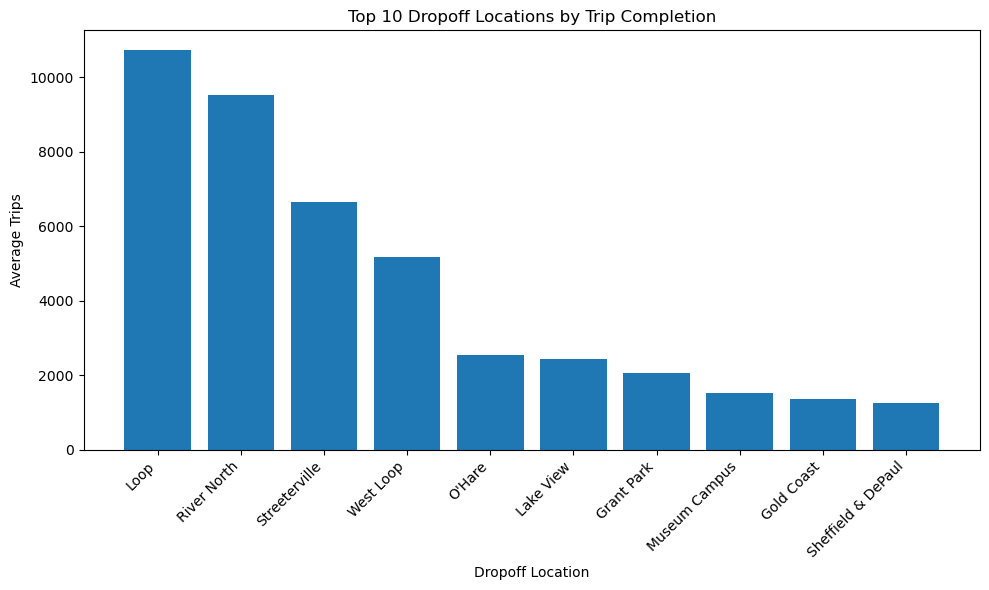

In [23]:
#Bar chart of the top 10 neighborhoods
plt.figure(figsize=(10, 6))
plt.bar(top_10_dropoffs['dropoff_location_name'], top_10_dropoffs['average_trips'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Dropoff Location")
plt.ylabel("Average Trips")
plt.title("Top 10 Dropoff Locations by Trip Completion")
plt.tight_layout()
plt.show()

OBSERVATIONS
- The chart displays the top 10 neghborhoods by average taxi trip drop offs, highlighting a strong spatial concentration of urban mobility activity in strategically important areas of Chicago.
- With more than 10,000 average trips completions, **Loop** stands out as the primary destination. This finding is consistent with its role as Chicago's financial, commercial and cultural center. The high concentration of trips suggests strong transportation demand associated with business activities, tourims and daily commuting patterns. 
- **River North** ~9500 average trips and **Streeterville** ~6600 average trips also exhibit high levels of mobility activity. These neighborhoods are characterized by a dense concentration of restaurants, hotels, entertainment venues, and tourist attractions, making them important urban mobility hubs that attract a large volume of trips.
- **West Loop** reflects a pattern of recent urban growth linked to commercial and corporate development, while **O'hare** funtions as a key regional transportation hub due to the busiest airports in the world.
- The remaining neighborhoods show moderate levels of activity, indicating a more stable distribution of transportation demand. Overall, the analysis revels that urban mobility in Chicago is not evenly distributed across the city. Instead, trip destinations are spatially concentrated in areas with high connectivity, economic activity, and strategic importance within the urban structure.

<Axes: xlabel='hour'>

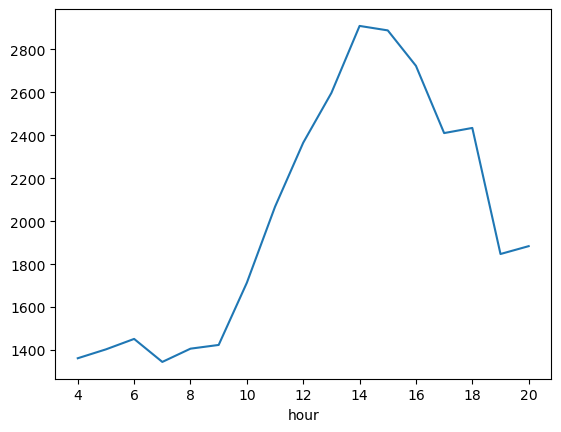

In [31]:
#Plot by hour
trip_counts = weather_df.groupby('hour').size()

valid_hours = trip_counts[trip_counts >= 10].index

hourly_duration = (
    weather_df[weather_df['hour'].isin(valid_hours)]
    .groupby('hour')['duration_seconds']
    .mean()
)

hourly_duration.plot()

OBSERVATIONS
- Trip duration varies throughout the day, with average travel times generally increasing from the morning hours and reaching their highest levels during the early afternoon.
- The longest average trip durations occur between approximately 2:00 PM and 4:00 PM, suggesting that traffic conditions and transportation demand may affect travel efficiency along the Loop–O'Hare corridor during these periods.
- Very early morning and late evening hours contain a limited number of observations, making those averages less reliable for interpretation. Overall, the analysis highlights the temporal variability of urban mobility patterns and complements the spatial and weather-related findings of the study.


# Geospatial analysis

In [35]:
#Install GeoPandas for geospatial data analysis
!pip install geopandas

In [36]:
#Load the Chicago neighborhood boundaries
import geopandas as gpd

chicago_map = gpd.read_file(
    "Neighborhoods_Chicago2012b.geojson"
)


#GeoJSON data source
#https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Neighborhoods/bbvz-uum9

In [39]:
#Preview the chicago_map dataset 
chicago_map.head(3)

,:id,:version,:created_at,:updated_at,pri_neigh,sec_neigh,shape_area,shape_len,geometry
0,row-4fxa-3c8r_bu6g,rv-a63d.7j6e~vwnn,2015-12-02 17:43:36.929000+00:00,2015-12-02 17:43:36.929000+00:00,Grand Boulevard,BRONZEVILLE,48492503.1554,28196.837157,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
1,row-vpnw~gzt3-rt75,rv-rsmh_pwu2.fxbg,2015-12-02 17:43:36.929000+00:00,2015-12-02 17:43:36.929000+00:00,Printers Row,PRINTERS ROW,2162137.97139,6864.247156,"MULTIPOLYGON (((-87.62761 41.87437, -87.6276 4..."
2,row-t44k-9bjd-m2xm,rv-gmsv_wtz8.wut5,2015-12-02 17:43:36.929000+00:00,2015-12-02 17:43:36.929000+00:00,United Center,UNITED CENTER,32520512.7053,23101.363745,"MULTIPOLYGON (((-87.66707 41.88885, -87.66707 ..."


In [41]:
#Verify consistency in format and content between chicago_map['pri_neigh'] 
#and neighborhood_df['dropoff_location_name']
print('chicago_map neighborhoods sorted alphabetically')
print()
print(sorted(chicago_map['pri_neigh'].unique()))
print()
print()
print('neighborhood_df neighborhoods sorted alphabetically')
print()
print(sorted(neighborhood_df['dropoff_location_name'].unique()))

chicago_map neighborhoods sorted alphabetically

['Albany Park', 'Andersonville', 'Archer Heights', 'Armour Square', 'Ashburn', 'Auburn Gresham', 'Austin', 'Avalon Park', 'Avondale', 'Belmont Cragin', 'Beverly', 'Boystown', 'Bridgeport', 'Brighton Park', 'Bucktown', 'Burnside', 'Calumet Heights', 'Chatham', 'Chicago Lawn', 'Chinatown', 'Clearing', 'Douglas', 'Dunning', 'East Side', 'East Village', 'Edgewater', 'Edison Park', 'Englewood', 'Fuller Park', 'Gage Park', 'Galewood', 'Garfield Park', 'Garfield Ridge', 'Gold Coast', 'Grand Boulevard', 'Grand Crossing', 'Grant Park', 'Greektown', 'Hegewisch', 'Hermosa', 'Humboldt Park', 'Hyde Park', 'Irving Park', 'Jackson Park', 'Jefferson Park', 'Kenwood', 'Lake View', 'Lincoln Park', 'Lincoln Square', 'Little Italy, UIC', 'Little Village', 'Logan Square', 'Loop', 'Lower West Side', 'Magnificent Mile', 'Mckinley Park', 'Millenium Park', 'Montclare', 'Morgan Park', 'Mount Greenwood', 'Museum Campus', 'Near South Side', 'New City', 'North Cente

Note: A visual inspection comfirmed that the neighborhood names in neighborhood_df were present in chicago_map and shares a consistent format, allowing the datasets to be joined correctly.

In [44]:
#merge chicago_map and neighborhood_df
geo_data = chicago_map.merge(
    neighborhood_df,
    left_on='pri_neigh',
    right_on='dropoff_location_name'
)

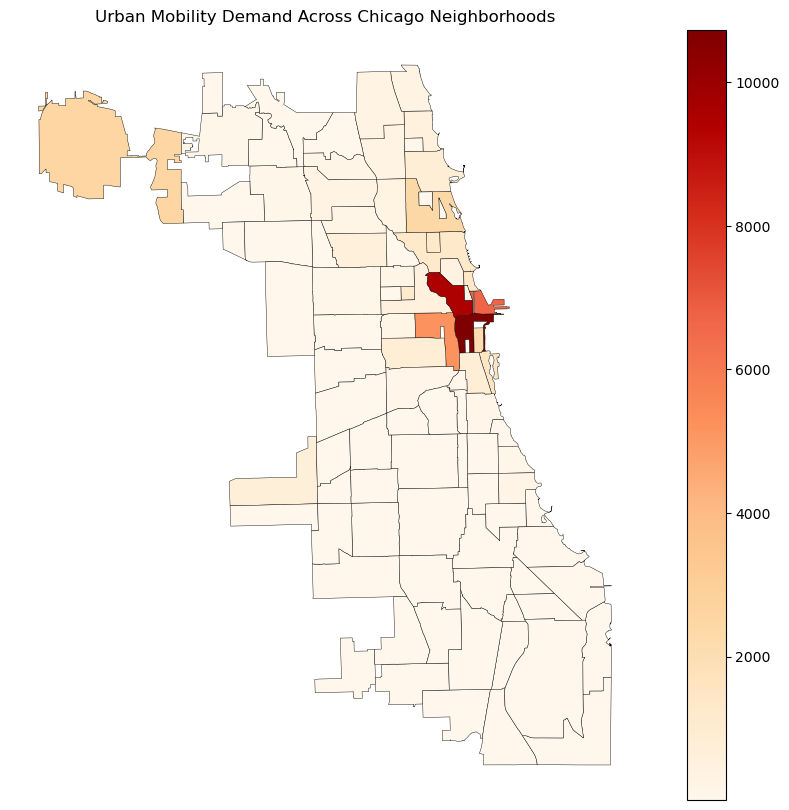

In [46]:
#Create a GIS choropleth map to visualize the spatial distribution
geo_data.plot(
    column='average_trips',
    cmap='OrRd',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    figsize=(12,10)
)

plt.title("Urban Mobility Demand Across Chicago Neighborhoods")
plt.axis('off')
plt.show()

OBSERVATIONS
- The choropleth map reveals a strong spatial concentration of urban mobility demand within central Chicago. The highest levels of trip drop-offs are clustered around the Loop and surrounding neighborhoods, forming a clear urban mobility hotspot. 
- The color intensity highlights a pattern of spatial clustering, where areas characterized by high economic activity, connectivity, and service density exhibit significantly greater transportation demand than the rest of the city.
- As distance from the urban core increases, trip demand decreases substantially, suggesting a highly centralized mobility structure.
- The spatial visualization also helps identify important urban corridors connected to strategic areas such as River North, Streeterville, and West Loops, reinforcing the idea that urban mobility is strongly influenced by the city's economic and funtional structure.
- Overall, the geospatial analysis demonstrates how GIS tools can reveal spatial mobility patterns and territorial dynamics that may not be immediately apparent through traditional tables or charts alone.

# Weather impact analysis

In [50]:
#Explore the distribution of weather conditions
weather_df['weather_conditions'].value_counts()

weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

<Axes: xlabel='weather_conditions'>

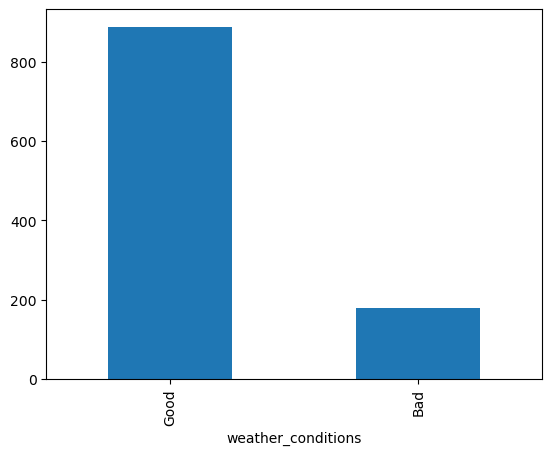

In [52]:
#Visualize the number of trips recorded under each weather condition
weather_df['weather_conditions'].value_counts().plot(
    kind='bar'
)

OBSERVATIONS
- The majority of trips occurred under **good weather conditions**, while only a small proportion of trips were recorded under **adverse weather conditions**. This indicates that most taxi operations took place during favorable weather, with relatively fewer trips occurring during periods of rain or other unfavorable conditions.


In [55]:
#Avg duration by weather: Good or Bad 
weather_df.groupby('weather_conditions')['duration_seconds'].mean()

weather_conditions
Bad     2427.205556
Good    1999.675676
Name: duration_seconds, dtype: float64

In [57]:
#Rainy days vs no rainy days
rainy = weather_df[
    weather_df['weather_conditions'] == 'Bad'
]

normal = weather_df[
    weather_df['weather_conditions'] == 'Good'
]

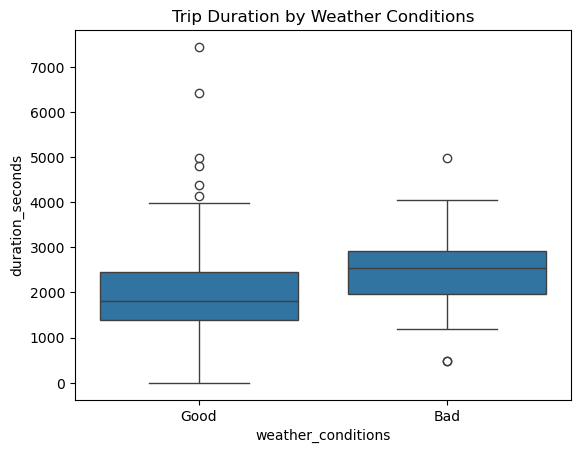

In [59]:
#Trip duration by weather condition boxplot 
sns.boxplot(
    data=weather_df,
    x='weather_conditions',
    y='duration_seconds'
)

plt.title(
    'Trip Duration by Weather Conditions'
)

plt.show()

OBSERVATIONS
- The median trip duration under bad weather conditions is noticeably higher than under good weather conditions, suggesting that trips tend to take longer when weather conditions are unfavorable.
- Both groups contain outliers, representing unusually long trips. However, the overall distribution for bad weather conditions remains centered at higher travel durations.
- Trips under good weather conditions exhibit greater variability, including several extreme observations with exceptionally long travel times. This suggests that factors other than weather, such as traffic incidents, congestion, or operational conditions, may also influence trip duration.
The visual separation between the two distributions provides preliminary evidence that weather conditions may affect travel times. This observation is later evaluated formally through statistical hypothesis testing.

# Hypothesis testing

Before performing the t-test, Levene's test will be applied to determine whether the variances of the two groups (trips under rainy weather conditions versus trips under normal weather conditions) can be considered equal. This step is importat because the standard independent samples t-test assumes homogenity of variances, and Levene's test helps verify whether this assumption is satisfied.

The dataset will be divided into two groups:
Rainy: Trips recorder under Bad conditions.
Normal: Trips recorder under Good conditions. 


In [63]:
#Apply Levene's test to assess the equality of variances between groups
stat_lev, p_lev = levene(normal['duration_seconds'], rainy['duration_seconds'])
print("\nLevene's tests:")
print("Statistic:", stat_lev)
print("p-value:", p_lev)



Levene's tests:
Statistic: 0.38853489683656073
p-value: 0.5332038671974493


### Hypothesis formulation
- Null Hypothesis(H₀): The average trip duration under rainy weather conditions is equal to the average trip duration under normal weather conditions. 

- Alternative Hypothesis (H₁): The average trip duration under rainy weather conditions is different to the average trip duration under normal weather conditions.


In [66]:
#Significance level
alpha = 0.05

#Perform the appopiate T-test based on Levene's test
if p_lev > alpha:
    print("\nEqual variances → Standar t-test")
    stat_t, p_t = ttest_ind(normal['duration_seconds'], rainy['duration_seconds'], equal_var=True)
else:
    print("\nDifferent variances → Welch t-test")
    stat_t, p_t = ttest_ind(normal['duration_seconds'], rainy['duration_seconds'], equal_var=False)



Equal variances → Standar t-test


In [68]:
#Apply the t-test standar
print("T-test results:")
print("Statistic:", stat_t)
print("p-value:", p_t)

print()
if p_t < alpha:
    print("Reject H₀: The average trip duration differs significantly between trips under rainy and non-rainy weather conditions")
    
else:
    print("Fail to reject H₀: No statistically significant difference was found in the average trip duration between trips under rainy and non-rainy weather conditinos.") 
    

T-test results:
Statistic: -6.946177714041499
p-value: 6.517970327099473e-12

Reject H₀: The average trip duration differs significantly between trips under rainy and non-rainy weather conditions


# Conclusions
- The analysis identified a strong spatial concentration of taxi trip destinations within Chicago's urban core. Neighborhoods such as **Loop**, **River North**, **Streeterville**, and **West Loop** emerged as major mobility hubs, reflecting the influence of economic activity, tourism, and transportation connectivity on travel demand.
- The choropleth map further revealed that urban mobility demand is not evenly distributed across the city. Instead, trip destinations are clustered around strategically important neighborhoods, demonstrating the value of geospatial analysis for understanding urban transportation patterns.
- Temporal analysis showed that trip durations vary throughout the day, with longer average travel times occurring during the afternoon hours. This finding suggests that traffic conditions and travel demand may influence transportation efficiency along the Loop–O'Hare corridor.
- Weather conditions were found to be an important factor affecting travel duration. The boxplot visualization indicated longer travel times under adverse weather conditions, providing preliminary evidence of a relationship between weather and transportation performance.
- Statistical hypothesis testing confirmed this relationship. Since the p-value obtained from the t-test (p ≈ 6.5 × 10⁻¹²) was lower than the significance level (α = 0.05), the null hypothesis was rejected. The results provide strong statistical evidence that weather conditions significantly affect the duration of taxi trips between the Loop and O'Hare International Airport.
- Overall, this project demonstrates how the integration of SQL, Python, statistical analysis, and GIS tools can be used to uncover spatial, temporal, and environmental factors influencing urban mobility systems. These techniques provide valuable insights for transportation planning, mobility management, and data-driven decision-making in urban environments.